In [64]:
import numpy as np
import random
import math
import copy
import pandas as pd
import time
import json
import matplotlib.pyplot as plt
import random2

In [2]:
pip install py2opt

Note: you may need to restart the kernel to use updated packages.


In [65]:
# === Load dataset ===

# Load only the CUSTOMER section of the text file
data = pd.read_fwf("rc104_100.txt", skiprows=8, header=None)
data.columns = ["CUST_NO", "XCOORD", "YCOORD", "DEMAND", "READY_TIME", "DUE_DATE", "SERVICE_TIME"]


# Load data from previous period
data_pre = pd.read_fwf("rc103_100.txt", skiprows=8, header=None)
data_pre.columns = ["CUST_NO", "XCOORD", "YCOORD", "DEMAND", "READY_TIME", "DUE_DATE", "SERVICE_TIME"]


In [66]:
# === Sets ===
V = list(range(25))  # 25 vehicles
C = list(range(1, len(data)))  # Customers (1 to n), excluding depot (0)
N = list(range(len(data)))  # All nodes including depot
# === Parameters ===
dc = data['DEMAND'].tolist()
dc[0] = 0  # Depot demand = 0
dc_pre = data_pre['DEMAND'].tolist()
dc_pre[0] = 0  # Depot demand = 0
coords = list(zip(data['XCOORD'], data['YCOORD']))
ai = data['READY_TIME'].tolist()
bi = data['DUE_DATE'].tolist()
si = data['SERVICE_TIME'].tolist()

In [67]:
# Problem parameters
cij = 30
delta = 0.17        #https://progresschamber.org/wp-content/uploads/2024/06/Chamber-of-Progress-Efficiency-and-Emissions-Impact-of-Last-Mile-Online-Delivery-in-the-US.pdf
lambda_v = 200
pi = 10
theta = 0.7
mv = 100000
cv = 100
hv = 15
ev = 0.1
cf = 0.5                                                                                        
fv = 0.1
gamma = 0.1
M = 1000000
w1, w2, w3 = 1, 1, 1  # weight for objectives
alpha_w, beta_w, gamma_w = 1, 1, 1  # penalty weights

dc_rev = [round(d * delta) for d in dc_pre]  # Integer reverse demand!!!!

In [68]:
# === Distance matrix ===
t = np.zeros((len(N), len(N)))
for i in N:
    for j in N:
        t[i][j] = math.hypot(coords[i][0] - coords[j][0], coords[i][1] - coords[j][1])

In [69]:
# === Initialize weights and scores ===
destruction_weights = [1.0] * 6
repair_weights = [1.0] * 5
destruction_scores = [0] * 6
repair_scores = [0] * 5
destruction_usage = [1] * 6
repair_usage = [1] * 5
alpha = 0.4  # weight update parameter

In [70]:
# === Roulette Wheel Selection ===
def select_operator(weights):
    total = sum(weights)
    r = random.uniform(0, total)
    cumulative = 0
    for i, w in enumerate(weights):
        cumulative += w
        if r <= cumulative:
            return i
    return len(weights) - 1  # fallback


In [71]:
# === Update Weights ===
def update_weights(weights, scores, usage):
    for i in range(len(weights)):
        weights[i] = alpha * weights[i] + (1 - alpha) * (scores[i] / usage[i] if usage[i] else 0)
        scores[i] = 0
        usage[i] = 1

In [72]:
# === Destruction Operators ===

# 1. Random Destroy Operator
def random_destroy(routes, fraction=0.4):
    all_customers = [(v, cust) for v in range(len(routes)) for cust in routes[v] if cust != 0]
    num_remove = max(1, int(len(all_customers) * fraction))
    to_remove = random.sample(all_customers, num_remove)
    removed = []
    for v, cust in to_remove:
        if cust in routes[v]:
            routes[v].remove(cust)
            removed.append(cust)
    return removed, routes

# 2. Similarity Destroy Operator
def similarity_destroy(routes, coords, q=5):
    # Normalize distances
    max_dist = max(math.dist(a, b) for a in coords for b in coords if a != b)

    def similarity(i, j):
        dist = math.dist(coords[i], coords[j]) / max_dist  # normalized c_ij
        same_route = any(i in r and j in r for r in routes)
        Vij = 0 if same_route else 1
        return 1 / (dist + Vij)

    all_customers = [cust for r in routes for cust in r if cust != 0]
    seed = random.choice(all_customers)
    removed = [seed]

    while len(removed) < q:
        curr = random.choice(removed)
        candidates = [c for c in all_customers if c not in removed]
        if not candidates:
            break

        candidates.sort(key=lambda j: -similarity(curr, j))
        rand_index = int(random.random() * len(candidates))
        selected = candidates[rand_index]
        removed.append(selected)

    for v in range(len(routes)):
        routes[v] = [c for c in routes[v] if c not in removed]

    return removed, routes


# 3. Maximum Saving Cost Destroy Operator
def max_saving_destroy(routes, coords, q=5):
    savings = []
    for v, route in enumerate(routes):
        for i in range(1, len(route) - 1):
            prev, curr, next_ = route[i-1], route[i], route[i+1]
            saving = t[prev][curr] + t[curr][next_] - t[prev][next_]
            savings.append((saving, v, curr))
    savings.sort(reverse=True)
    removed = [cust for _, v, cust in savings[:q]]
    for _, v, cust in savings[:q]:
        routes[v].remove(cust)
    return removed, routes

# 4. Destroying Vehicle Destroy Operator
def destroying_vehicle_destroy(routes):
    max_cost = -1
    vehicle_to_remove = -1

    for v, route in enumerate(routes):
        if not route or len(route) < 2:
            continue

        # Path length
        path_length = sum(t[route[i]][route[i+1]] for i in range(len(route) - 1))

        # Average waiting time
        time = 0
        wait_total = 0
        visits = 0

        for i in range(1, len(route)):
            prev = route[i - 1]
            curr = route[i]
            travel = t[prev][curr]
            time += travel

            if curr != 0:  # Ignore depot
                wait = max(0, ai[curr] - time)
                wait_total += wait
                time += si[curr]
                visits += 1

        avg_wait = wait_total / visits if visits > 0 else 0

        # Weighted cost metric
        cost = 0.7 * path_length + 0.3 * avg_wait

        if cost > max_cost:
            max_cost = cost
            vehicle_to_remove = v

    # Remove all customers from that vehicle's route
    removed = [cust for cust in routes[vehicle_to_remove] if cust != 0]
    routes[vehicle_to_remove] = []

    return removed, routes


# 5. Maximum Waiting Time Destroy Operator 
def max_waiting_time_destroy(routes, ai, bi, si):
    def calc_wait(route):
        time = 0
        wait_total = 0
        for i in range(1, len(route)):
            prev = route[i - 1]
            curr = route[i]
            travel = t[prev][curr]
            time += travel

            # Actual waiting if early
            if curr != 0:
                wait = max(0, ai[curr] - time)

                # Penalty if late
                late_penalty = max(0, time - bi[curr]) * 10

                wait_total += wait + late_penalty

                time += si[curr]
        return wait_total

    vehicle_to_remove = max(range(len(routes)), key=lambda v: calc_wait(routes[v]))
    removed = [cust for cust in routes[vehicle_to_remove] if cust != 0]
    routes[vehicle_to_remove] = []
    return removed, routes

# 6. 2-Opt Search Algorithm

from py2opt.routefinder import RouteFinder

def destroy_2opt(routes, dist_matrix, iterations=10):
    """
    Applies 2-opt on each non-empty route using py2opt and returns the new solution.
    No customers are removed, so `removed_customers` is an empty list.
    """
    new_solution = []
    removed_customers = []  # 2-opt does not remove, just reorders within a route

    for route in routes:
        if len(route) <= 3:  # No improvement possible for short routes
            new_solution.append(route)
            continue

        # Ensure route starts and ends at depot
        if route[0] != 0:
            route = [0] + route
        if route[-1] != 0:
            route.append(0)

        # Convert to string labels for py2opt
        route_labels = [str(c) for c in route]
        submatrix = [[dist_matrix[a][b] for b in route] for a in route]

        # Run 2-opt
        rf = RouteFinder(submatrix, route_labels, iterations=iterations)
        _, best_route = rf.solve()

        # Convert back to integers
        optimized_route = [int(c) for c in best_route]

        # Double-check depot structure
        if optimized_route[0] != 0:
            optimized_route = [0] + optimized_route
        if optimized_route[-1] != 0:
            optimized_route.append(0)

        new_solution.append(optimized_route)

    return removed_customers, new_solution



destruction_ops = [
    lambda r: random_destroy(r, fraction=0.4),
    lambda r: similarity_destroy(r, coords, q=5),
    lambda r: max_saving_destroy(r, coords, q=5),
    lambda r: max_waiting_time_destroy(r, ai, bi, si),
    lambda r: destroying_vehicle_destroy(r),
    lambda r: destroy_2opt(r, t)
]

In [73]:
# === Repair Operators ===

# Delta cost evaluation function
def delta_insertion_cost(route, i, cust):
    prev = route[i - 1]
    next_ = route[i] if i < len(route) else 0
    delta = t[prev][cust] + t[cust][next_] - t[prev][next_]
    return delta

# 1. Global Optimal Repair Operator
def global_optimal_repair(routes, removed):
    for cust in removed:
        best_cost = float('inf')
        best_pos = None
        for v, route in enumerate(routes):
            for i in range(1, len(route)):
                if not is_time_window_feasible(route, i, cust, ai, bi, si, t):
                    continue
                if not is_capacity_feasible(route, i, cust, dc, dc_rev, lambda_v):
                    continue
                delta = delta_insertion_cost(route, i, cust)
                if delta < best_cost:
                    best_cost = delta
                    best_pos = (v, i)
        if best_pos:
            v, i = best_pos
            routes[v].insert(i, cust)
        else:
            # Start a new route if no feasible position found
            routes.append([0, cust, 0])
    return routes

# 2. Minimum Insertion Cost Repair Operator
def min_insertion_cost_repair(routes, removed):
    pending = removed[:]
    while pending:
        best_costs = []

        for cust in pending:
            best_delta = float("inf")
            best_wait = float("inf")
            best_pos = None

            for v, route in enumerate(routes):
                for i in range(1, len(route)):
                    if not is_time_window_feasible(route, i, cust, ai, bi, si, t):
                        continue
                    if not is_capacity_feasible(route, i, cust, dc, dc_rev, lambda_v):
                        continue

                    # Delta cost (local evaluation)
                    prev, next_ = route[i - 1], route[i]
                    delta_cost = t[prev][cust] + t[cust][next_] - t[prev][next_]

                    # Estimate waiting time after insertion
                    arrival = 0
                    for j in range(1, i):
                        arrival += t[route[j - 1]][route[j]] + si[route[j - 1]]
                    arrival += t[route[i - 1]][cust]
                    wait_time = max(0, ai[cust] - arrival)

                    if (delta_cost < best_delta) or (delta_cost == best_delta and wait_time < best_wait):
                        best_delta = delta_cost
                        best_wait = wait_time
                        best_pos = (v, i)

            best_costs.append((best_delta, cust, best_pos))

        # Choose customer with largest minimum insertion cost
        best_costs.sort(reverse=True)
        _, selected_cust, selected_pos = best_costs[0]

        if selected_pos:
            v, i = selected_pos
            routes[v].insert(i, selected_cust)
        else:
            # No feasible insertion thencreate a new route
            routes.append([0, selected_cust, 0])

        pending.remove(selected_cust)

    return routes

# 3. Random K Repair Operator
def random_k_repair(routes, removed, ai, bi, si, t, dc, dc_rev, lambda_v, current_iter):
    
    k_dynamic = 5 + current_iter // 500

    for cust in removed:
        candidates = []

        for v, route in enumerate(routes):
            for i in range(1, len(route)):  # Skip depot at 0
                if not is_time_window_feasible(route, i, cust, ai, bi, si, t):
                    continue
                if not is_capacity_feasible(route, i, cust, dc, dc_rev, lambda_v):
                    continue

                prev, next_ = route[i - 1], route[i]
                delta_cost = t[prev][cust] + t[cust][next_] - t[prev][next_]

                candidates.append((delta_cost, v, i))

        if candidates:
            candidates.sort()
            chosen = random.choice(candidates[:min(k_dynamic, len(candidates))])
            _, v, i = chosen
            routes[v].insert(i, cust)
        else:
            routes.append([0, cust, 0])  # New route if no insertion possible

    return routes


# 4. Regret Criterion Repair Operator
def regret_repair(routes, removed, ai, bi, si, t, dc, dc_rev, lambda_v, k=5):

    while removed:
        regrets = []

        for cust in removed:
            candidate_positions = []

            for v, route in enumerate(routes):
                for i in range(1, len(route)):
                    if not is_time_window_feasible(route, i, cust, ai, bi, si, t):
                        continue
                    if not is_capacity_feasible(route, i, cust, dc, dc_rev, lambda_v):
                        continue
                    prev, next_ = route[i - 1], route[i]
                    delta = t[prev][cust] + t[cust][next_] - t[prev][next_]
                    candidate_positions.append((delta, v, i))

            if len(candidate_positions) >= k:
                candidate_positions.sort()
                regret = sum(candidate_positions[j][0] - candidate_positions[0][0] for j in range(1, k))
                regrets.append((regret, cust, candidate_positions[0]))

        if regrets:
            regrets.sort(reverse=True)  # Max regret first
            _, chosen_cust, (best_delta, v, i) = regrets[0]
            routes[v].insert(i, chosen_cust)
            removed.remove(chosen_cust)
        else:
            # No feasible insertion for any customer, create new route for one
            chosen_cust = removed.pop(0)
            routes.append([0, chosen_cust, 0])

    return routes


# 5. Minimum Waiting Time Repair Operator
def min_waiting_time_repair(routes, removed, ai, bi, si, t, dc, dc_rev, lambda_v):
    for cust in removed:
        best_pos = None
        min_wait = float('inf')

        for v, route in enumerate(routes):
            time = 0  # cumulative time along the route

            for i in range(1, len(route)):
                prev = route[i - 1]
                departure_prev = time + si[prev]
                travel = t[prev][cust]
                arrival = max(departure_prev + travel, ai[cust])
                wait = arrival - departure_prev - travel

                if not is_time_window_feasible(route, i, cust, ai, bi, si, t):
                    continue
                if not is_capacity_feasible(route, i, cust, dc, dc_rev, lambda_v):
                    continue

                if wait < min_wait:
                    min_wait = wait
                    best_pos = (v, i)

                # update time to next node
                next_node = route[i]
                time = departure_prev + t[prev][next_node]

        if best_pos:
            v, i = best_pos
            routes[v].insert(i, cust)
        else:
            routes.append([0, cust, 0])  # New route for isolated customer

    return routes


repair_ops = [
    lambda r, rem: global_optimal_repair(r, rem),
    lambda r, rem: min_insertion_cost_repair(r, rem),
    lambda r, rem: regret_repair(r, rem, ai, bi, si, t, dc, dc_rev, lambda_v, k=5),
    lambda r, rem: random_k_repair(r, rem, ai, bi, si, t, dc, dc_rev, lambda_v, current_iter=0),
    lambda r, rem: min_waiting_time_repair(r, rem, ai, bi, si, t, dc, dc_rev, lambda_v)
]


In [74]:
# === 1. Nearest Neighbor Heuristic ===
def nearest_neighbor_initial_solution():
    unvisited = set(C)
    routes = [[] for _ in V]
    v = 0

    while unvisited:
        if v >= len(V):
            raise RuntimeError("Insufficient vehicles.")
        route = [0]
        load = 0
        curr = 0
        while True:
            nearest = None
            nearest_dist = float('inf')
            for cust in unvisited:
                if dc[cust] + load <= lambda_v and t[curr][cust] < nearest_dist:
                    nearest = cust
                    nearest_dist = t[curr][cust]
            if nearest is None:
                break
            route.append(nearest)
            load += dc[nearest]
            curr = nearest
            unvisited.remove(nearest)
        route.append(0)
        routes[v] = route
        v += 1
    return routes
initial_routes = nearest_neighbor_initial_solution()

import json
with open("routes_nns.json", "w") as f:
    json.dump(initial_routes, f)

    # Preview output
for v, route in enumerate(initial_routes):
    if route:
        print(f"Vehicle {v}: {route}")

Vehicle 0: [0, 2, 6, 4, 5, 3, 1, 0]


In [78]:
# === a Feasibility Checker Function ===

# Helper function for capacity check
def is_capacity_feasible(route, insert_pos, cust, dc, dc_rev, lambda_v):
    # Create a tentative new route with cust inserted at the position
    new_route = route[:insert_pos] + [cust] + route[insert_pos:]

    load = 0  # initial load is 0
    for node in new_route:
        if node == 0:
            continue  # depot, skip
        # Deliver forward items
        deliver = dc[node]
        if load >= deliver:
            load -= deliver
        else:
            deliver = load  # deliver what we can
            load = 0
        # Pick up reverse items (adds to load)
        pickup = dc_rev[node]
        load += pickup
        # Check capacity after pickup
        if load > lambda_v:
            return False
    return True


def is_time_window_feasible(route, insert_pos, cust, ai, bi, si, t):
    prev = route[insert_pos - 1]
    next_ = route[insert_pos] if insert_pos < len(route) else 0

    # Estimate earliest possible arrival at 'cust'
    est = max(ai[cust], ai[prev] + si[prev] + t[prev][cust])
    lst = bi[cust]

    # Check if insertion affects the next node's feasibility
    if next_ != 0:
        latest_next = bi[next_] - t[cust][next_] - si[cust]
        if est > latest_next:
            return False

    return est <= lst

# === Evaluation F(X) + penalty(X) with Forward/Backward Slack for Time Windows ===
def evaluate_with_penalty(routes):
    total_cost = 0
    Feco = Fenv = Fsoc = 0
    unmet_delivery = {i: dc[i] for i in C}
    unmet_return = {i: dc_rev[i] for i in C}

    penalty_tw_total = 0
    penalty_capacity_total = 0
    penalty_mv_total = 0

    for route in routes:
        # Skip trivial or empty routes
        if len(route) < 2:
            continue

        # Check if vehicle is used (serves any customer)
        is_used = any(node != 0 for node in route[1:-1])
        if not is_used:
            continue

        # === Earliest Start Times (Forward Pass) ===
        esi = {route[0]: 0}
        for i in range(1, len(route)):
            prev = route[i - 1]
            curr = route[i]
            travel = t[prev][curr]
            arrival = esi[prev] + si[prev] + travel
            esi[curr] = max(arrival, ai[curr])

        # === Latest Start Times (Backward Pass) ===
        lsi = {route[-1]: float('inf')}
        for i in reversed(range(len(route) - 1)):
            curr = route[i]
            succ = route[i + 1]
            travel = t[curr][succ]
            latest = lsi[succ] - si[curr] - travel
            lsi[curr] = min(latest, bi[curr])

        # === Time Window Penalty ===
        for i in range(1, len(route) - 1):
            curr = route[i]
            est = esi[curr]
            lst = lsi[curr]
            penalty_tw = max(0, est - bi[curr])  # soft constraint on late arrivals
            penalty_tw_total += 1e3 * penalty_tw

        # === Capacity check & unmet demand accounting ===
        load = 0
        for curr in route[1:-1]:
            if curr == 0:
                continue

            forward_demand = unmet_delivery[curr]
            reverse_demand = unmet_return[curr]

            # Deliver forward demand
            deliverable = min(lambda_v - load, forward_demand)
            unmet_delivery[curr] -= deliverable

            # Pick up reverse demand
            pickup = min(lambda_v - load - deliverable, reverse_demand)
            unmet_return[curr] -= pickup

            load += pickup  # only pickup adds to load

            if load > lambda_v:
                penalty_capacity_total += 1e6  # hard penalty

        # === Route end time
        beta_v = esi[route[-1]]
        if beta_v > mv:
            penalty_mv_total += 1e6

        # === Cost terms
        travel_cost = sum(
            t[route[i]][route[i + 1]] * (cf * fv + cij)
            for i in range(len(route) - 1)
        )
        env_cost = sum(
            t[route[i]][route[i + 1]] * ev * gamma
            for i in range(len(route) - 1)
        )

        if any(n != 0 for n in route[1:-1]):  # Vehicle is used
            Feco += hv * beta_v + cv + travel_cost
            Fenv += env_cost
            Fsoc += hv * beta_v

    # === Final Unmet Demand Penalty ===
    Feco += pi * (
        sum(unmet_delivery[i] for i in C) +
        (1 - theta) * sum(unmet_return[i] for i in C)
    )

    # === Total Cost
    violation_penalty = penalty_tw_total + penalty_capacity_total + penalty_mv_total
    total_cost = w1 * Feco + w2 * Fenv + w3 * Fsoc + violation_penalty

    return Feco, Fenv, Fsoc, total_cost, violation_penalty


In [79]:
def ialns_sa(initial_solution, evaluate_func, destruction_ops, repair_ops,
             T0=500, Tmin=0.01, cooling_rate=0.98, max_iter=50000,
             pool_max_size=10, reintro_interval=250):

    current = copy.deepcopy(initial_solution)
    best = copy.deepcopy(initial_solution)

    Feco_best, Fenv_best, Fsoc_best, best_cost, best_penalty = evaluate_func(best)
    current_cost = best_cost

    T = T0
    iteration = 0

    d_weights = [1.0] * len(destruction_ops)
    r_weights = [1.0] * len(repair_ops)

    feasible_pool = []

    while T > Tmin and iteration < max_iter:
        # === 1. Select operators using roulette wheel ===
        d_idx = select_operator(d_weights)
        r_idx = select_operator(r_weights)

        # === 2. Track usage of selected operators ===
        destruction_usage[d_idx] += 1
        repair_usage[r_idx] += 1

        # === 3. Apply destruction and repair ===
        removed, destroyed = destruction_ops[d_idx](copy.deepcopy(current))

        try:
            repaired = repair_ops[r_idx](copy.deepcopy(destroyed), removed)
        except TypeError:
            # For operators needing 'iteration' param
            repaired = repair_ops[r_idx](copy.deepcopy(destroyed), removed, iteration)

        # === 4. Evaluate solution ===
        Feco, Fenv, Fsoc, new_cost, penalty = evaluate_func(repaired)

        # === 5. Accept or reject ===
        if penalty == 0:
            feasible_pool.append(copy.deepcopy(repaired))
            if len(feasible_pool) > pool_max_size:
                feasible_pool.pop(0)

            if new_cost < best_cost:
                best = copy.deepcopy(repaired)
                best_cost = new_cost
                Feco_best, Fenv_best, Fsoc_best, best_penalty = Feco, Fenv, Fsoc, penalty

        delta = new_cost - current_cost
        if penalty == 0 and (delta < 0 or random.random() < math.exp(-delta / T)):
            current = copy.deepcopy(repaired)
            current_cost = new_cost

        # === 6. Diversification: Reintroduce from pool ===
        if iteration > 0 and iteration % reintro_interval == 0 and feasible_pool:
            current = copy.deepcopy(random.choice(feasible_pool))
            _, _, _, current_cost, _ = evaluate_func(current)

        # === 7. Print progress every 100 iterations or if penalty occurred ===
        if iteration % 100 == 0 or penalty > 0:
            print(f"Iteration {iteration+1}: Cost = {new_cost:.2f}, Penalty = {penalty:.2f}")
            for v, r in enumerate(repaired):
                if r:
                    print(f"  Vehicle {v}: {r}")

        # === 8. Cooling schedule ===
        T *= cooling_rate
        iteration += 1

    return best, best_cost, Feco_best, Fenv_best, Fsoc_best, best_penalty


In [80]:
# Run initial solution evaluation
Feco, Fenv, Fsoc, total_cost, violation_penalty = evaluate_with_penalty(initial_routes)
print("\nInitial Solution (NNS):")
for v, r in enumerate(initial_routes):
    if r: print(f"Vehicle {v}: {r}")
print(f"Breakdown: total = {total_cost:.4f}, Feco = {Feco:.4f}, Fenv = {Fenv:.4f}, Fsoc = {Fsoc:.2f}, Penalty = {violation_penalty:.2f}")

# Run IALNS-SA
lns_routes, lns_cost, Feco, Fenv, Fsoc, penalty = ialns_sa(
    initial_routes, evaluate_with_penalty, destruction_ops, repair_ops
)

# Final solution output
print("\nFinal Solution (IALNS-SA):")
for v, r in enumerate(lns_routes):
    if r: print(f"Vehicle {v}: {r}")
print(f"Final Cost: {lns_cost:.2f}")
print(f"Breakdown: Feco = {Feco:.2f}, Fenv = {Fenv:.2f}, Fsoc = {Fsoc:.2f}, Penalty = {penalty:.2f}")


Initial Solution (NNS):
Vehicle 0: [0, 2, 6, 4, 5, 3, 1, 0]
Breakdown: total = 9625.7584, Feco = 6188.6927, Fenv = 0.8827, Fsoc = 3436.18, Penalty = 0.00
Iteration 1: Cost = 13514.03, Penalty = 2825.47
  Vehicle 25: [0, 6, 3, 4, 2, 1, 5, 0]
0 msec
0 msec
0 msec
0 msec
0 msec
0 msec
0 msec
0 msec
0 msec
0 msec
0 msec
1 msec
1 msec
1 msec
1 msec
1 msec
1 msec
1 msec
1 msec
1 msec
Iteration 5: Cost = 17110.96, Penalty = 6591.72
  Vehicle 25: [0, 5, 4, 3, 1, 6, 2, 0]
0 msec
0 msec
0 msec
1 msec
1 msec
1 msec
1 msec
1 msec
1 msec
1 msec
0 msec
0 msec
1 msec
1 msec
1 msec
1 msec
1 msec
1 msec
1 msec
1 msec
Iteration 18: Cost = 12511.08, Penalty = 2440.31
  Vehicle 25: [0, 6, 4, 5, 3, 1, 2, 0]
Iteration 22: Cost = 83633.56, Penalty = 71345.41
  Vehicle 25: [0, 4, 5, 6, 3, 2, 1, 0]
0 msec
0 msec
0 msec
0 msec
0 msec
0 msec
0 msec
0 msec
0 msec
0 msec
Iteration 26: Cost = 29517.37, Penalty = 18372.96
  Vehicle 27: [0, 3, 4, 2, 5, 1, 6, 0]
Iteration 31: Cost = 13916.90, Penalty = 3583.20
  Vehi

In [16]:
Feco, Fenv, Fsoc, total_cost, penalty = evaluate_with_penalty(lns_routes)

print(f"\n--- Final Evaluation ---")
print(f"  Feco:   {Feco:.2f}")
print(f"  Fenv:   {Fenv:.2f}")
print(f"  Fsoc:   {Fsoc:.2f}")
print(f"  Total:  {total_cost:.2f}")
print(f"  Penalty:{penalty:.2f}")



--- Final Evaluation ---
  Feco:   5702.52
  Fenv:   0.93
  Fsoc:   2805.83
  Total:  8509.29
  Penalty:0.00


In [54]:
destruction_op_names = ['Random Destroy', 'Similarity Destroy', 'Max Saving Destroy', 'Max Wait Destroy', 'Destroy Route', '2-opt']
repair_op_names = ['Global Optimal Repair', 'Min Insertion Cost', 'Regret Repair', 'Random-k Repair', 'Min Waiting Time']

# Operator usage summary
print("\n=== Operator Usage Summary ===")

print("\nDestruction Operators Usage:")
for idx, count in enumerate(destruction_usage):
    print(f"  D{idx+1} - {destruction_op_names[idx]}: used {count} times")

print("\nRepair Operators Usage:")
for idx, count in enumerate(repair_usage):
    print(f"  R{idx+1} - {repair_op_names[idx]}: used {count} times")




=== Operator Usage Summary ===

Destruction Operators Usage:
  D1 - Random Destroy: used 108 times
  D2 - Similarity Destroy: used 95 times
  D3 - Max Saving Destroy: used 75 times
  D4 - Max Wait Destroy: used 88 times
  D5 - Destroy Route: used 91 times
  D6 - 2-opt: used 85 times

Repair Operators Usage:
  R1 - Global Optimal Repair: used 95 times
  R2 - Min Insertion Cost: used 109 times
  R3 - Regret Repair: used 104 times
  R4 - Random-k Repair: used 123 times
  R5 - Min Waiting Time: used 110 times


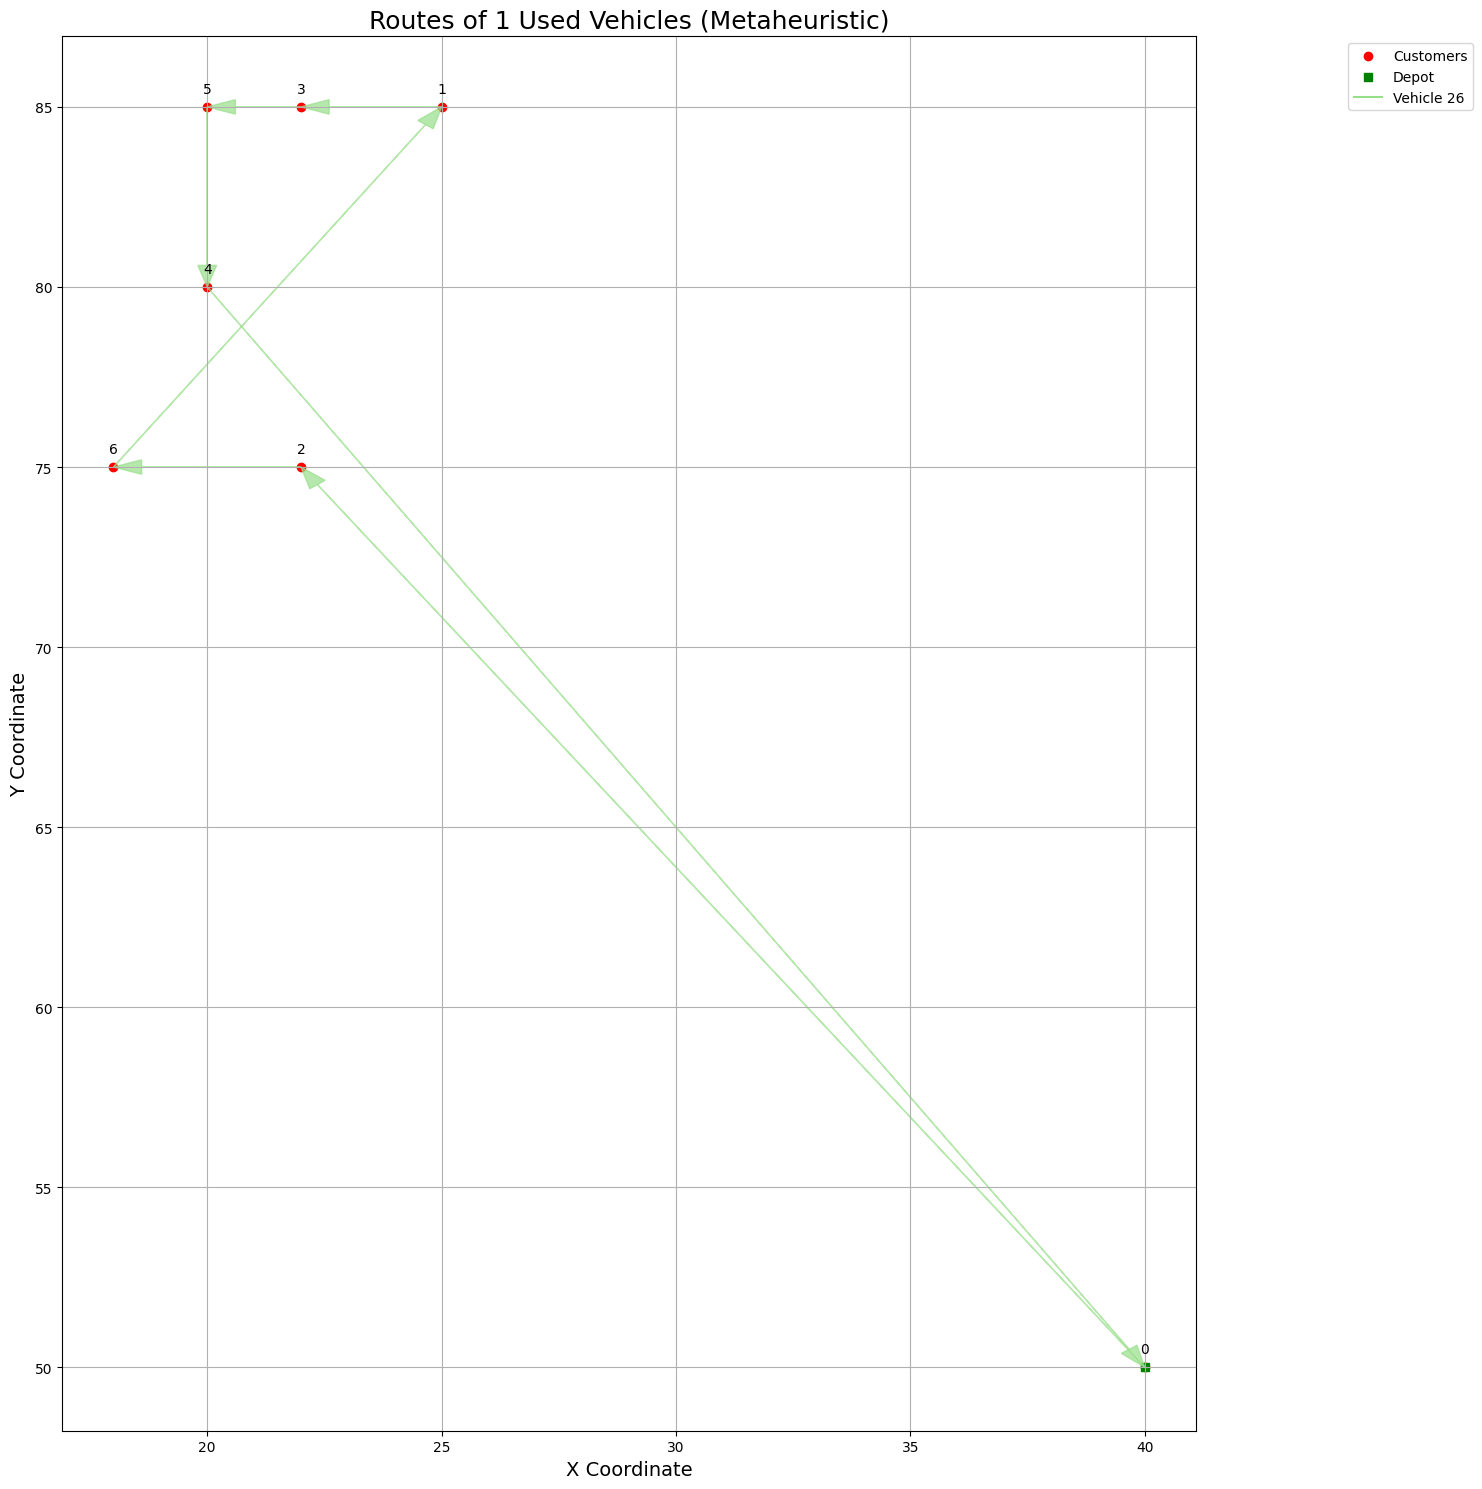

In [18]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def plot_metaheuristic_routes(routes, coords, V):
    # Extract X and Y coordinates
    xc = [c[0] for c in coords]
    yc = [c[1] for c in coords]

    plt.figure(figsize=(15, 15))
    plt.scatter(xc, yc, c='red', label='Customers')
    plt.scatter(xc[0], yc[0], c='green', marker='s', label='Depot')

    for i, (x, y_) in enumerate(zip(xc, yc)):
        plt.annotate(str(i), (x, y_), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10)

    cmap = plt.get_cmap('tab20', len(V))
    used_vehicle_count = 0

    for v, route in enumerate(routes):
        if not route or len(route) < 2:
            continue
        used_vehicle_count += 1
        color = cmap(v % 20)

        for i in range(len(route) - 1):
            a, b = route[i], route[i + 1]
            plt.arrow(xc[a], yc[a], xc[b] - xc[a], yc[b] - yc[a],
                      color=color, head_width=0.4, length_includes_head=True, alpha=0.7)

        plt.plot([], [], color=color, label=f'Vehicle {v}')

    plt.xlabel('X Coordinate', fontsize=14)
    plt.ylabel('Y Coordinate', fontsize=14)
    plt.title(f'Routes of {used_vehicle_count} Used Vehicles (Metaheuristic)', fontsize=18)
    plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1), fontsize=10)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Call the function
plot_metaheuristic_routes(lns_routes, coords, V)


In [19]:
import matplotlib.pyplot as plt

def plot_vehicle_load_dynamics(routes, dc, dc_rev, lambda_v):
    for v, route in enumerate(routes):
        if not route or len(route) < 3:
            continue  # Skip empty or trivial routes

        cust_nodes = []
        remaining_load = []
        cumulative_reverse = []
        net_vehicle_load = []

        load = sum(dc[node] for node in route if node != 0)  # Start with total forward delivery
        rev_total = 0

        for i in range(1, len(route) - 1):  # skip depot at start/end
            node = route[i]
            forward = dc[node]
            reverse = dc_rev[node]

            load -= forward                 # Deliver forward demand
            rev_total += reverse            # Pickup reverse demand
            net_load = load + rev_total     # Net load carried by vehicle

            cust_nodes.append(str(node))
            remaining_load.append(load)
            cumulative_reverse.append(rev_total)
            net_vehicle_load.append(net_load)

        plt.figure(figsize=(12, 6))
        plt.plot(cust_nodes, remaining_load, marker='o', label='Remaining Forward Load', color='blue')
        plt.plot(cust_nodes, cumulative_reverse, marker='s', label='Cumulative Reverse Pickup', color='orange')
        plt.plot(cust_nodes, net_vehicle_load, marker='^', label='Net Vehicle Load', color='green')
        plt.axhline(y=lambda_v, color='red', linestyle='--', label=f'Capacity ({lambda_v})', alpha=0.6)

        # Optional: annotate points
        for idx in range(len(cust_nodes)):
            plt.text(cust_nodes[idx], net_vehicle_load[idx] + 2, f'{net_vehicle_load[idx]:.0f}', ha='center', fontsize=8, color='green')

        plt.title(f'Vehicle Load Dynamics - Vehicle {v}', fontsize=14)
        plt.xlabel('Customer Node', fontsize=12)
        plt.ylabel('Quantity', fontsize=12)
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


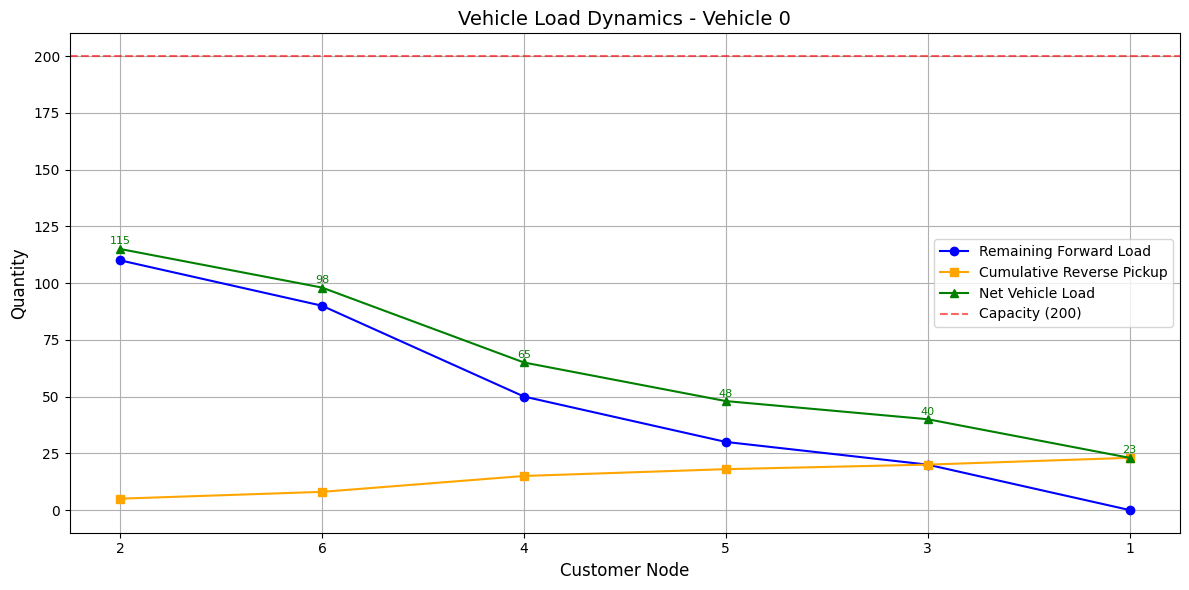

In [20]:
plot_vehicle_load_dynamics(initial_routes, dc, dc_rev, lambda_v)


In [21]:
def plot_objective_over_time(iterations, times):
    plt.figure(figsize=(12, 6))
    plt.plot(iterations, label="Objective Value")
    plt.xlabel("Iteration")
    plt.ylabel("Objective Value")
    plt.title("Objective Value Progress Over Iterations")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(times, iterations, label="Objective vs Time")
    plt.xlabel("Time (s)")
    plt.ylabel("Objective Value")
    plt.title("Objective Value vs Time")
    plt.grid(True)
    plt.legend()
    plt.show()


In [22]:
lns_routes, lns_cost, obj_history, time_history = ialns_sa(
    initial_routes, evaluate_with_penalty, destruction_ops, repair_ops
)

plot_objective_over_time(obj_history, time_history)


Iteration 1: Cost = 9030.93, Penalty = 0.00
  Vehicle 0: [0, 2, 5, 1, 6, 3, 4, 0]
Iteration 2: Cost = 9287.99, Penalty = 0.00
  Vehicle 25: [0, 3, 6, 1, 5, 2, 4, 0]
Iteration 3: Cost = 17721.46, Penalty = 0.00
  Vehicle 25: [0, 2, 0]
  Vehicle 26: [0, 3, 5, 4, 6, 0]
  Vehicle 27: [0, 1, 0]
Iteration 4: Cost = 19515.41, Penalty = 8511.37
  Vehicle 0: [0, 6, 5, 4, 1, 2, 3, 0]
Iteration 5: Cost = 16741.34, Penalty = 0.00
  Vehicle 0: [0, 2, 0]
  Vehicle 25: [0, 6, 0]
  Vehicle 26: [0, 1, 3, 5, 4, 0]
Iteration 6: Cost = 9089.12, Penalty = 0.00
  Vehicle 25: [0, 1, 3, 5, 4, 6, 2, 0]
Iteration 7: Cost = 19039.75, Penalty = 0.00
  Vehicle 25: [0, 6, 4, 2, 0]
  Vehicle 26: [0, 5, 0]
  Vehicle 27: [0, 1, 3, 0]
Iteration 8: Cost = 9278.75, Penalty = 0.00
  Vehicle 26: [0, 5, 3, 6, 1, 4, 2, 0]
Iteration 9: Cost = 18670.49, Penalty = 0.00
  Vehicle 26: [0, 6, 0]
  Vehicle 27: [0, 2, 4, 5, 0]
  Vehicle 28: [0, 1, 3, 0]
Iteration 10: Cost = 9352.72, Penalty = 0.00
  Vehicle 26: [0, 1, 2, 5, 6, 3, 4,

ValueError: too many values to unpack (expected 4)